<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/Spoofed_Traffic_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[[374.54011885 950.71430641]
 [731.99394181 598.6584842 ]
 [156.01864044 155.99452034]
 [ 58.08361217 866.17614577]
 [601.11501174 708.0725778 ]]


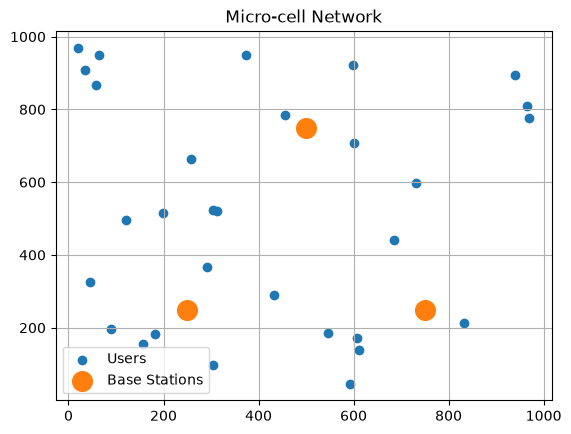

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Base station positions
bs_positions = np.array([
    [250,250],
    [750,250],
    [500,750]
])

# Random users
# Fix random numbers
np.random.seed(42)

num_users = 30

# Generate only ONCE
user_positions = np.random.uniform(
    low=0,
    high=1000,
    size=(num_users,2)
)

print(user_positions[:5])

plt.scatter(user_positions[:,0],user_positions[:,1],label='Users')
plt.scatter(bs_positions[:,0],bs_positions[:,1],s=200,label='Base Stations')

plt.legend()
plt.grid()
plt.title("Micro-cell Network")
plt.savefig("network.png")
plt.show()

In [ ]:
import numpy as np


assignments = []

for user in user_positions:

    d1 = np.linalg.norm(user-bs_positions[0])
    d2 = np.linalg.norm(user-bs_positions[1])

    if d1 < d2:
        assignments.append(0)
    else:
        assignments.append(1)

print(assignments)

print("Users connected to BS1:",assignments.count(0))
print("Users connected to BS2:",assignments.count(1))

[0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0]
Users connected to BS1: 18
Users connected to BS2: 12
Users connected to BS3: 0


In [ ]:
users_bs1 = 12
users_bs2 = 8

print("BS1 Load:",users_bs1)
print("BS2 Load:",users_bs2)

BS1 Load: 12
BS2 Load: 8


In [ ]:
users_bs1 = 12
users_bs2 = 8

print("Before Attack")
print("BS1:",users_bs1)
print("BS2:",users_bs2)

spoofed_users = 30

users_bs2 += spoofed_users

print("\nAfter Attack")
print("BS1:",users_bs1)
print("BS2:",users_bs2)

Before Attack
BS1: 12
BS2: 8

After Attack
BS1: 12
BS2: 38


In [ ]:
capacity = 100

normal_load = 10
attack_load = 40

throughput_normal = capacity/normal_load
throughput_attack = capacity/attack_load

print("Normal:",throughput_normal)
print("Attack:",throughput_attack)

Normal: 10.0
Attack: 2.5


In [ ]:
P_idle = 30
P_user = 2

normal_users = 10
attack_users = 40

normal_power = P_idle + P_user*normal_users
attack_power = P_idle + P_user*attack_users

print("Normal Power =",normal_power,"W")
print("Attack Power =",attack_power,"W")

Normal Power = 50 W
Attack Power = 110 W


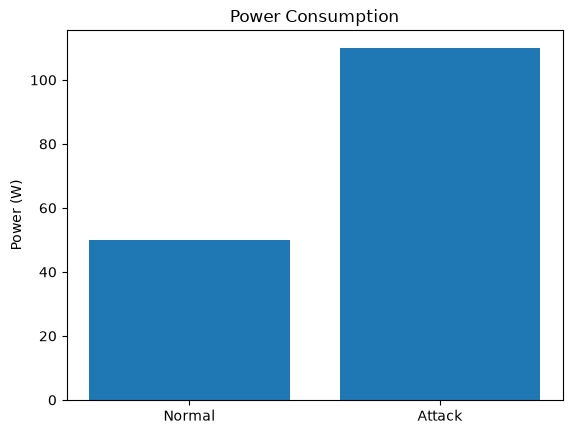

In [ ]:
import matplotlib.pyplot as plt

scenarios = ["Normal","Attack"]
power = [50,110]

plt.bar(scenarios,power)

plt.ylabel("Power (W)")
plt.title("Power Consumption")

plt.savefig("power_comparison.png")
plt.show()

In [ ]:
!pip install sionna

In [ ]:
pip show sionna


Name: sionna
Version: 2.0.1
Summary: Sionna - A hardware-accelerated differentiable open-source library for research on communication systems
Home-page: 
Author: 
Author-email: The Sionna contributors <sionna@nvidia.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: h5py, importlib-resources, matplotlib, numpy, scipy, sionna-rt, torch
Required-by: 


In [ ]:
import tensorflow as tf
import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

TensorFlow: 2.20.0
Sionna: 2.0.1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation area (meters)
AREA_X = 1000
AREA_Y = 1000

print("Simulation Area:", AREA_X, "x", AREA_Y, "meters")

Simulation Area: 1000 x 1000 meters


In [ ]:
bs_positions = np.array([
    [250,250],
    [750,250],
    [500,750]
])

print(bs_positions)

[[250 250]
 [750 250]
 [500 750]]


In [ ]:
num_users = 30

user_positions = np.random.rand(num_users,2)

user_positions[:,0] *= AREA_X
user_positions[:,1] *= AREA_Y

print(user_positions)

[[615.0072267  990.0538501 ]
 [140.08401524 518.32965236]
 [877.37307193 740.76861775]
 [697.015741   702.48408399]
 [359.49115122 293.59184426]
 [809.36115548 810.11339468]
 [867.07231858 913.24055256]
 [511.34239886 501.51629469]
 [798.29517897 649.96393078]
 [701.96687726 795.79266944]
 [890.00534182 337.99515685]
 [375.58295264  93.98193984]
 [578.280141    35.9422738 ]
 [465.59801813 542.64463471]
 [286.54125213 590.83326057]
 [ 30.50024994  37.34818875]
 [822.60056066 360.19064141]
 [127.06051265 522.24326005]
 [769.9935531  215.8210275 ]
 [622.89047582  85.34746499]
 [ 51.68172117 531.35463157]
 [540.63512161 637.4299015 ]
 [726.09133372 975.85207946]
 [516.3003483  322.95647294]
 [795.18619477 270.83225126]
 [438.97142071  78.45638134]
 [ 25.35074342 962.64841468]
 [835.98012051 695.97420609]
 [408.95294441 173.29432007]
 [156.43704267 250.24289816]]


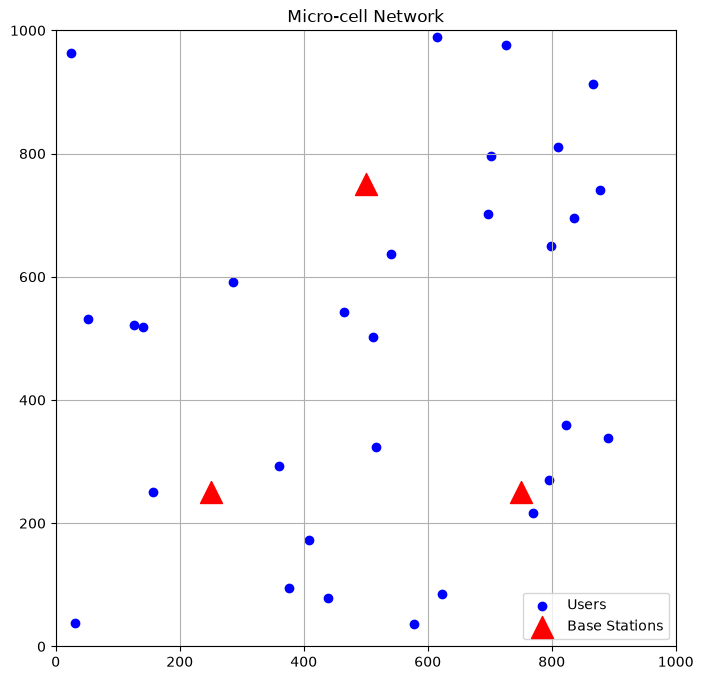

In [ ]:
plt.figure(figsize=(8,8))

# Users
plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c='blue',
    label='Users'
)

# Base Stations
plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    c='red',
    s=250,
    marker='^',
    label='Base Stations'
)

plt.xlim(0,AREA_X)
plt.ylim(0,AREA_Y)

plt.grid(True)
plt.legend()

plt.title("Micro-cell Network")

plt.savefig("figures_network_layout_1.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import tensorflow as tf
import sionna
import numpy as np
import matplotlib.pyplot as plt

# Simulation area (meters)
AREA_X = 1000
AREA_Y = 1000

bs_positions = np.array([
    [250,250],
    [750,250],
    [500,750]
])

num_users = 30

user_positions = np.random.rand(num_users,2)

user_positions[:,0] *= AREA_X
user_positions[:,1] *= AREA_Y


# Distance matrix
distance_matrix = np.zeros((len(user_positions), len(bs_positions)))

for i, user in enumerate(user_positions):

    for j, bs in enumerate(bs_positions):

        distance = np.linalg.norm(user-bs)

        distance_matrix[i,j] = distance

print(distance_matrix)

[[552.61737962 506.12182679  60.63590692]
 [411.28813021  94.66017819 496.6138749 ]
 [857.25052651 529.16272029 455.02627196]
 [472.72961356 411.24109112 148.57831284]
 [169.61523983 330.40772866 508.66325685]
 [518.78500415 642.77927929 144.24087751]
 [271.01100683 747.69878774 798.54716893]
 [292.24879168 734.44313205 842.12780082]
 [756.56326382 465.75464373 358.4687166 ]
 [270.93975034 315.01510952 652.6770052 ]
 [329.11679301 341.61672724 276.65530016]
 [199.2470369  605.39037967 454.69418021]
 [394.84167762 507.34132099 168.21856358]
 [436.11646192 234.74223626 717.5282107 ]
 [395.97850947 531.21216603 176.44477022]
 [657.19699701 654.8065625  106.53601454]
 [417.86468924 126.16365124 608.13621469]
 [431.49561332 784.61437466 442.70171946]
 [403.3515034  797.60963181 501.15985349]
 [763.11940523 376.98937016 473.56301381]
 [416.85315313 534.41241103 154.57480302]
 [361.60552059 415.33800938 208.60325492]
 [704.7322256  234.90998492 572.11228584]
 [967.09693515 688.5389736  486.65

In [ ]:
assignments = np.argmin(distance_matrix, axis=1)

print(assignments)

[2 1 2 2 0 2 0 0 2 0 2 0 2 1 2 2 1 0 0 1 2 2 1 2 0 0 2 0 1 1]


In [ ]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments==bs)

    print(f"BS {bs+1} has {count} users")

BS 1 has 10 users
BS 2 has 7 users
BS 3 has 13 users


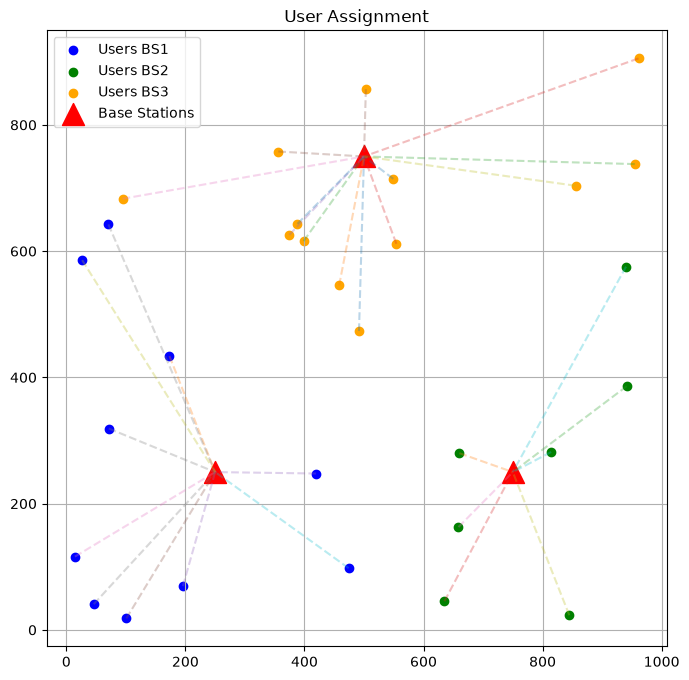

In [ ]:
plt.figure(figsize=(8,8))

colors=['blue','green','orange']

# Draw users

for bs in range(3):

    idx = assignments==bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users BS{bs+1}'
    )

# Draw Base Stations

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=250,
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs=assignments[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3
    )

plt.grid()

plt.legend()

plt.title("User Assignment")

plt.savefig("figures_network_layout_2.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "User": range(1, len(assignments)+1),
    "Assigned_BS": assignments
})

results.to_csv("user_assignment.csv", index=False)

In [ ]:
# -------------------------------
# Network Parameters
# -------------------------------

frequency = 3500      # MHz (5G frequency)
tx_power = 30         # dBm (micro-cell transmit power)

print("Frequency:", frequency, "MHz")
print("Transmit Power:", tx_power, "dBm")

Frequency: 3500 MHz
Transmit Power: 30 dBm


In [ ]:
distance_matrix
print(distance_matrix)

[[552.61737962 506.12182679  60.63590692]
 [411.28813021  94.66017819 496.6138749 ]
 [857.25052651 529.16272029 455.02627196]
 [472.72961356 411.24109112 148.57831284]
 [169.61523983 330.40772866 508.66325685]
 [518.78500415 642.77927929 144.24087751]
 [271.01100683 747.69878774 798.54716893]
 [292.24879168 734.44313205 842.12780082]
 [756.56326382 465.75464373 358.4687166 ]
 [270.93975034 315.01510952 652.6770052 ]
 [329.11679301 341.61672724 276.65530016]
 [199.2470369  605.39037967 454.69418021]
 [394.84167762 507.34132099 168.21856358]
 [436.11646192 234.74223626 717.5282107 ]
 [395.97850947 531.21216603 176.44477022]
 [657.19699701 654.8065625  106.53601454]
 [417.86468924 126.16365124 608.13621469]
 [431.49561332 784.61437466 442.70171946]
 [403.3515034  797.60963181 501.15985349]
 [763.11940523 376.98937016 473.56301381]
 [416.85315313 534.41241103 154.57480302]
 [361.60552059 415.33800938 208.60325492]
 [704.7322256  234.90998492 572.11228584]
 [967.09693515 688.5389736  486.65

In [ ]:
distance_km = distance_matrix / 1000

# Avoid log10(0)
distance_km[distance_km < 0.001] = 0.001

import numpy as np

path_loss = 32.44 \
            + 20*np.log10(frequency) \
            + 20*np.log10(distance_km)

print(path_loss)

[[ 98.16985167  97.40646223  78.97595844]
 [ 95.60428441  82.84470724  97.24173787]
 [101.9835161   97.79314569  96.48209033]
 [ 96.81361707  95.60329094  86.76046934]
 [ 87.9106583   93.70236484  97.44996824]
 [ 97.62110917  99.48259825  86.503128  ]
 [ 91.98109948 100.79589442 101.36737237]
 [ 92.63641537 100.64052437 101.82892098]
 [100.89826588  96.68450476  94.41038611]
 [ 91.97881541  93.28798859  99.61532713]
 [ 93.66836174  93.99214344  92.16014078]
 [ 89.30919832  98.96207119  96.4757488 ]
 [ 95.24982066  97.42736559  87.83883929]
 [ 96.11341049  90.73318564 100.4381405 ]
 [ 95.27479322  97.82672114  88.2535367 ]
 [ 99.67527229  99.64362135  83.87128981]
 [ 95.74207436  85.34004587  99.00137822]
 [ 96.02088859 101.2144861   96.24358506]
 [ 95.43503449 101.35716868  97.32088636]
 [100.97321083  94.84794298  96.8289164 ]
 [ 95.72102271  97.8788916   87.10413492]
 [ 94.48606193  95.68939443  89.7077825 ]
 [100.28184351  90.73939043  98.47098637]
 [103.03076103 100.07993144  97.06

In [ ]:
received_power = tx_power - path_loss

print(received_power)

[[-68.16985167 -67.40646223 -48.97595844]
 [-65.60428441 -52.84470724 -67.24173787]
 [-71.9835161  -67.79314569 -66.48209033]
 [-66.81361707 -65.60329094 -56.76046934]
 [-57.9106583  -63.70236484 -67.44996824]
 [-67.62110917 -69.48259825 -56.503128  ]
 [-61.98109948 -70.79589442 -71.36737237]
 [-62.63641537 -70.64052437 -71.82892098]
 [-70.89826588 -66.68450476 -64.41038611]
 [-61.97881541 -63.28798859 -69.61532713]
 [-63.66836174 -63.99214344 -62.16014078]
 [-59.30919832 -68.96207119 -66.4757488 ]
 [-65.24982066 -67.42736559 -57.83883929]
 [-66.11341049 -60.73318564 -70.4381405 ]
 [-65.27479322 -67.82672114 -58.2535367 ]
 [-69.67527229 -69.64362135 -53.87128981]
 [-65.74207436 -55.34004587 -69.00137822]
 [-66.02088859 -71.2144861  -66.24358506]
 [-65.43503449 -71.35716868 -67.32088636]
 [-70.97321083 -64.84794298 -66.8289164 ]
 [-65.72102271 -67.8788916  -57.10413492]
 [-64.48606193 -65.68939443 -59.7077825 ]
 [-70.28184351 -60.73939043 -68.47098637]
 [-73.03076103 -70.07993144 -67.06

In [ ]:
assignments_signal = np.argmax(received_power, axis=1)

print(assignments_signal)


[2 1 2 2 0 2 0 0 2 0 2 0 2 1 2 2 1 0 0 1 2 2 1 2 0 0 2 0 1 1]


In [ ]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments_signal == bs)

    print(f"BS {bs+1}: {count} users")

BS 1: 10 users
BS 2: 7 users
BS 3: 13 users


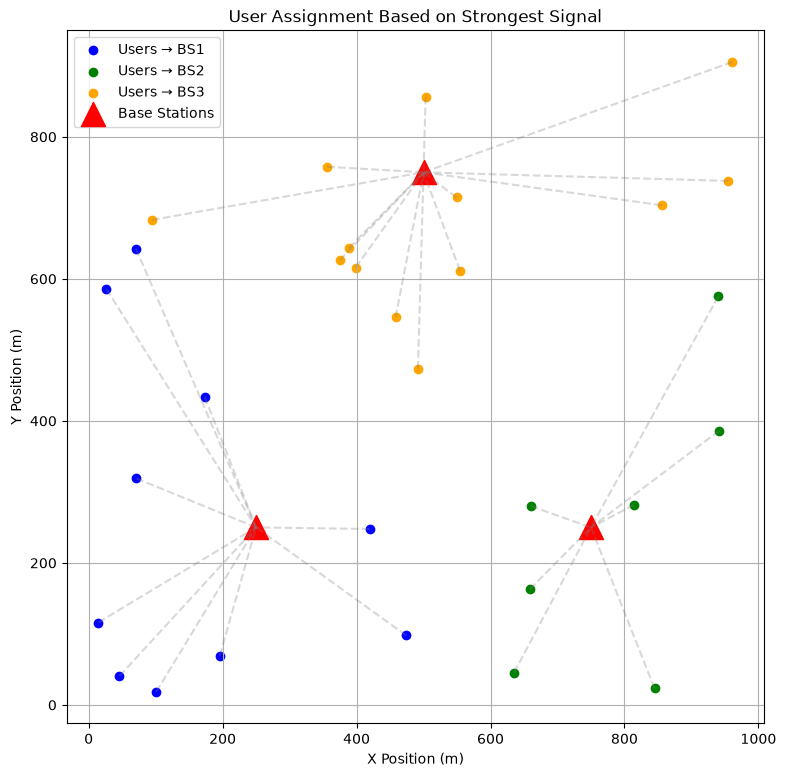

In [ ]:
plt.figure(figsize=(9,9))

colors = ['blue','green','orange']

for bs in range(3):

    idx = assignments_signal == bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users → BS{bs+1}'
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    s=300,
    color='red',
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs = assignments_signal[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3,
        color='gray'
    )

plt.title("User Assignment Based on Strongest Signal")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step4_user_assignment_signal.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "User": np.arange(1, len(user_positions)+1),
    "Assigned_BS": assignments_signal + 1,
    "Best_RSRP_dBm": np.max(received_power, axis=1)
})

print(results.head())

results.to_csv("step4_user_assignment.csv", index=False)

   User  Assigned_BS  Best_RSRP_dBm
0     1            3     -48.975958
1     2            2     -52.844707
2     3            3     -66.482090
3     4            3     -56.760469
4     5            1     -57.910658


In [ ]:
#STEP 5 - SINR Calculation
# Convert dBm to mW

received_power_mW = 10 ** (received_power / 10)

print(received_power_mW)

[[1.52410481e-07 1.81699519e-07 1.26591386e-05]
 [2.75151294e-07 5.19432688e-06 1.88723600e-07]
 [6.33356731e-08 1.66220824e-07 2.24797236e-07]
 [2.08275552e-07 2.75214243e-07 2.10840029e-06]
 [1.61783479e-06 4.26347299e-07 1.79888407e-07]
 [1.72937463e-07 1.12652329e-07 2.23710928e-06]
 [6.33709258e-07 8.32550447e-08 7.29898990e-08]
 [5.44952266e-07 8.62874358e-08 6.56308308e-08]
 [8.13155141e-08 2.14560377e-07 3.62210795e-07]
 [6.34042630e-07 4.69030561e-07 1.09261532e-07]
 [4.29698489e-07 3.98828014e-07 6.08115288e-07]
 [1.17241177e-06 1.26996830e-07 2.25125723e-07]
 [2.98550590e-07 1.80827068e-07 1.64481126e-06]
 [2.44714076e-07 8.44659043e-07 9.04036468e-08]
 [2.96838807e-07 1.64940720e-07 1.49501769e-06]
 [1.07763769e-07 1.08552009e-07 4.10082295e-06]
 [2.66558517e-07 2.92412149e-06 1.25852596e-07]
 [2.49983383e-07 7.56051519e-08 2.37487904e-07]
 [2.86085964e-07 7.31615894e-08 1.85315337e-07]
 [7.99243139e-08 3.27495775e-07 2.07543129e-07]
 [2.67853749e-07 1.62971191e-07 1.947989

In [ ]:
# Thermal Noise (Assume a simple fixed thermal noise power)
noise_dBm = -100

noise_mW = 10 ** (noise_dBm / 10)

print("Noise Power (mW):", noise_mW)

Noise Power (mW): 1e-10


In [ ]:
# Calculate SINR
sinr = []

for i in range(len(user_positions)):

    serving_bs = assignments_signal[i]

    signal = received_power_mW[i, serving_bs]

    interference = np.sum(received_power_mW[i]) - signal

    sinr_linear = signal / (interference + noise_mW)

    sinr.append(sinr_linear)

sinr = np.array(sinr)

# Convert SINR to dB
sinr_dB = 10 * np.log10(sinr)

print(sinr_dB)

[15.78384716 10.49034795 -0.09287769  6.39475939  4.26221026  8.93792477
  6.07806212  5.54462687  0.87705052  0.39896111 -1.34372898  5.22263008
  5.35347695  4.01354464  5.10117618 12.775821    8.72143455 -0.97900982
  0.43906782  0.56465987  6.55184878  2.32740735  5.53117691  1.23043191
  7.72746161  5.69565527 -0.30300102  7.48744187  6.15229106 14.88830896]


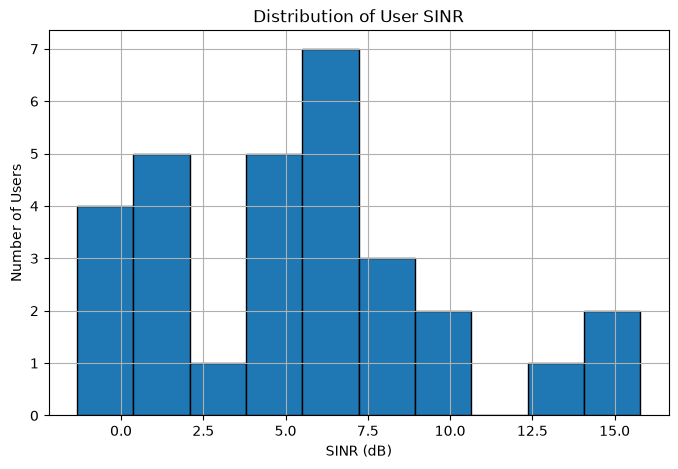

In [ ]:
# Plot SINR Distribution
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=10,
         edgecolor='black')

plt.xlabel("SINR (dB)")
plt.ylabel("Number of Users")
plt.title("Distribution of User SINR")

plt.grid(True)

plt.savefig("figures_step5_sinr_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

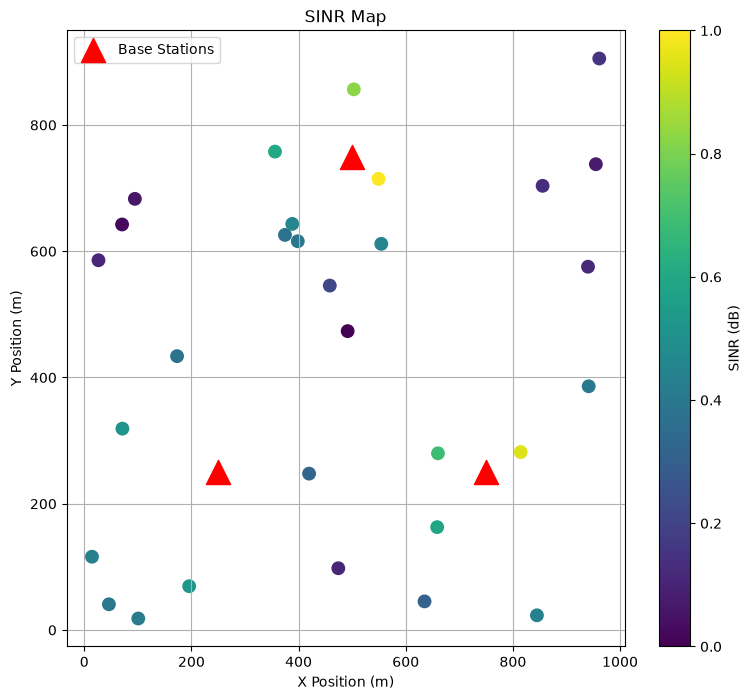

In [ ]:
# Network Visualization
plt.figure(figsize=(9,8))

plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c=sinr_dB,
    cmap='viridis',
    s=80
)

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=300,
    label='Base Stations'
)

plt.colorbar(label="SINR (dB)")

plt.title("SINR Map")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step5_sinr_map.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
# Statistics
print("Average SINR :", np.mean(sinr_dB))

print("Maximum SINR :", np.max(sinr_dB))

print("Minimum SINR :", np.min(sinr_dB))

Average SINR : 5.19443358075058
Maximum SINR : 15.783847161601091
Minimum SINR : -1.3437289797938068


In [ ]:
# Save Results
results["SINR_dB"] = sinr_dB

results.to_csv(
    "results_step5_sinr_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB
0     1            3     -48.975958  15.783847
1     2            2     -52.844707  10.490348
2     3            3     -66.482090  -0.092878
3     4            3     -56.760469   6.394759
4     5            1     -57.910658   4.262210


In [ ]:
#====================================================
# STEP 6 - QoS Analysis
#====================================================

# Spectral Efficiency (bits/s/Hz)

spectral_efficiency = np.log2(1 + sinr)

print(spectral_efficiency)


[5.28087458 3.60825047 0.98465583 2.42220449 1.87507869 3.14250392
 2.33721907 2.19685297 1.15301718 1.06778734 0.79400694 2.11390406
 2.1474445  1.81546585 2.08297947 4.31823129 3.0789138  0.84653475
 1.07477003 1.09683435 2.4647946  1.43775761 2.1933607  1.21879758
 2.79197837 2.23622848 0.95055026 2.72403377 2.35703106 4.99185634]


In [ ]:
# Bandwidth per user

bandwidth = 20e6      # 20 MHz

throughput = bandwidth * spectral_efficiency

throughput_Mbps = throughput / 1e6

print(throughput_Mbps)

[105.61749158  72.16500946  19.69311651  48.44408986  37.50157387
  62.85007832  46.74438142  43.93705945  23.06034356  21.3557468
  15.88013873  42.27808126  42.94888998  36.30931704  41.65958948
  86.3646257   61.57827603  16.93069509  21.49540061  21.93668707
  49.29589197  28.7551522   43.86721394  24.37595155  55.83956743
  44.72456954  19.0110052   54.48067545  47.1406211   99.83712672]


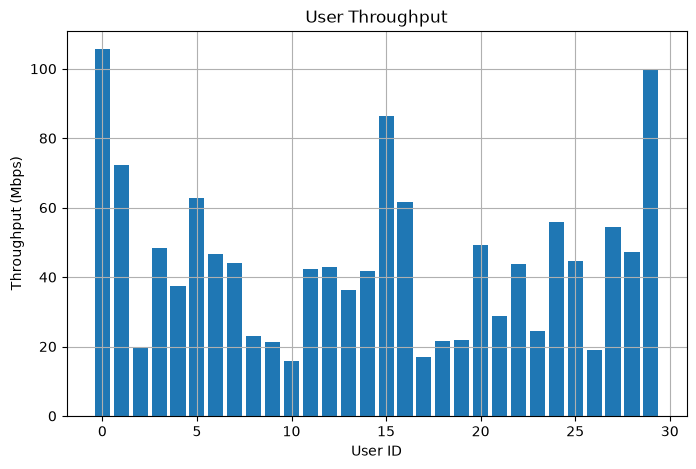

In [ ]:
# Plot Throughput

plt.figure(figsize=(8,5))

plt.bar(range(len(throughput_Mbps)),
        throughput_Mbps)

plt.xlabel("User ID")
plt.ylabel("Throughput (Mbps)")
plt.title("User Throughput")

plt.grid(True)

plt.savefig(
    "figures_step6_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Average Throughput
print("Average Throughput:")

print(np.mean(throughput_Mbps),"Mbps")

Average Throughput:
44.5359455635248 Mbps


In [ ]:
# Packet Error Rate (PER)
packet_error_rate = np.exp(-sinr)

print(packet_error_rate)

[3.54716692e-17 1.37389494e-05 3.75746270e-01 1.27797411e-02
 6.93758639e-02 3.97405341e-04 1.73653867e-02 2.77427294e-02
 2.94114894e-01 3.34133075e-01 4.80041143e-01 3.58428662e-02
 3.23732390e-02 8.04811200e-02 3.92889072e-02 5.89703037e-09
 5.81569469e-04 4.50148996e-01 3.30752049e-01 3.20187478e-01
 1.08837613e-02 1.81047695e-01 2.80519622e-02 2.65132262e-01
 2.66970128e-03 2.44374797e-02 3.93525411e-01 3.67142288e-03
 1.61934292e-02 4.12190197e-14]


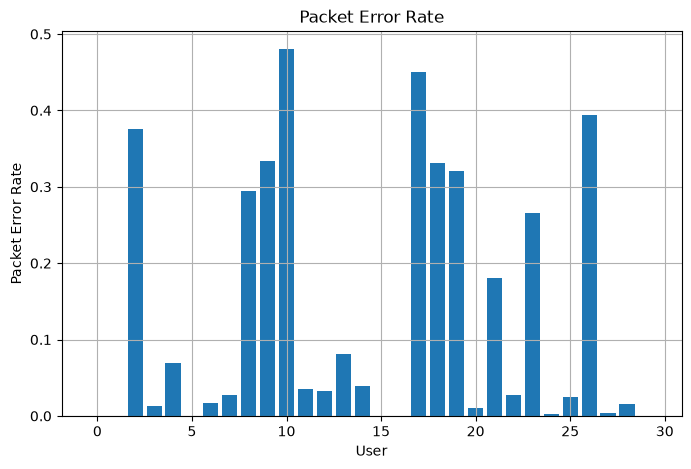

In [ ]:
# Plot PER
plt.figure(figsize=(8,5))

plt.bar(range(len(packet_error_rate)),
        packet_error_rate)

plt.xlabel("User")

plt.ylabel("Packet Error Rate")

plt.title("Packet Error Rate")

plt.grid(True)

plt.savefig(
    "figures_step6_packet_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Latency Model
latency = 100/(sinr+1)

print(latency)

[ 2.57216218  8.1998966  50.53462661 18.65708508 27.26120628 11.32431809
 19.78914147 21.81129036 44.96838018 47.70500896 57.67400295 23.10210052
 22.57120742 28.41124875 23.60264628  5.0128286  11.83462747 55.61188891
 47.47467303 46.75412776 18.11435575 36.91406162 21.86415205 42.96406555
 14.43878877 21.22404468 51.74350688 15.13505925 19.51924214  3.14268975]


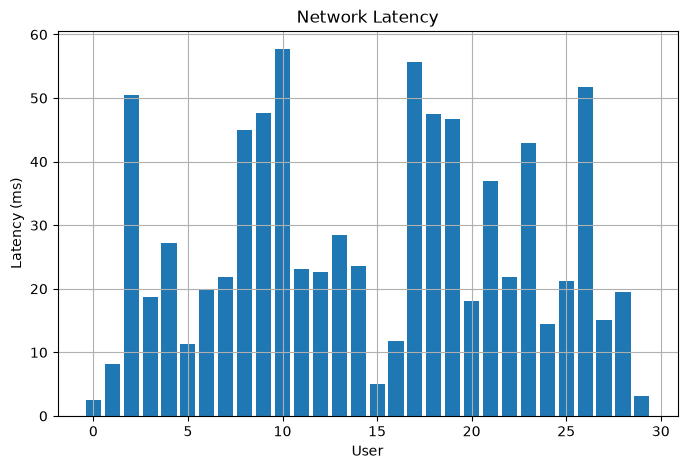

In [ ]:
# Plot Latency
plt.figure(figsize=(8,5))

plt.bar(range(len(latency)),
        latency)

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Network Latency")

plt.grid(True)

plt.savefig(
    "figures_step6_latency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# QoS Summary
print("========== QoS SUMMARY ==========")

print("Average SINR:",
      np.mean(sinr_dB),
      "dB")

print("Average Throughput:",
      np.mean(throughput_Mbps),
      "Mbps")

print("Average Latency:",
      np.mean(latency),
      "ms")

print("Average PER:",
      np.mean(packet_error_rate))

========== QoS SUMMARY ==========
Average SINR: 5.19443358075058 dB
Average Throughput: 44.5359455635248 Mbps
Average Latency: 27.331081130877926 ms
Average PER: 0.12756598681391326


In [ ]:
# Save Results
results["SINR_dB"] = sinr_dB
results["Spectral_Efficiency"] = spectral_efficiency
results["Throughput_Mbps"] = throughput_Mbps
results["Latency_ms"] = latency
results["PER"] = packet_error_rate

results.to_csv(
    "results_step6_qos_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB  Spectral_Efficiency  \
0     1            3     -48.975958  15.783847             5.280875   
1     2            2     -52.844707  10.490348             3.608250   
2     3            3     -66.482090  -0.092878             0.984656   
3     4            3     -56.760469   6.394759             2.422204   
4     5            1     -57.910658   4.262210             1.875079   

   Throughput_Mbps  Latency_ms           PER  
0       105.617492    2.572162  3.547167e-17  
1        72.165009    8.199897  1.373895e-05  
2        19.693117   50.534627  3.757463e-01  
3        48.444090   18.657085  1.277974e-02  
4        37.501574   27.261206  6.937586e-02  


In [ ]:
# Step 7
# Save normal network results

normal_throughput = throughput_Mbps.copy()
normal_latency = latency.copy()
normal_per = packet_error_rate.copy()
normal_assignments = assignments_signal.copy()

In [ ]:
# Number of users connected to each BS

cell_load = np.zeros(len(bs_positions), dtype=int)

for bs in assignments_signal:
    cell_load[bs] += 1

print("Current Cell Load")

for i, load in enumerate(cell_load):
    print(f"BS{i+1}: {load} users")

Current Cell Load
BS1: 10 users
BS2: 7 users
BS3: 13 users


In [ ]:
#----------------------------------------
# Spoofed Traffic Attack
#----------------------------------------

target_bs = 1      # BS2 (index starts from 0)

spoofed_users = 20

print("Attack Target : BS", target_bs+1)
print("Fake Users :", spoofed_users)

Attack Target : BS 2
Fake Users : 20


In [ ]:
# Increase Cell Load
attack_cell_load = cell_load.copy()

attack_cell_load[target_bs] += spoofed_users

print("Cell Load After Attack")

for i, load in enumerate(attack_cell_load):
    print(f"BS{i+1}: {load} users")

Cell Load After Attack
BS1: 10 users
BS2: 27 users
BS3: 13 users


In [ ]:
# Available Bandwidth Per Cell
total_bandwidth = 20e6      #20 MHz

bandwidth_per_bs = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):
    bandwidth_per_bs[i] = total_bandwidth / attack_cell_load[i]

print(bandwidth_per_bs)

[2000000.          740740.74074074 1538461.53846154]


In [ ]:
# Calculate New Throughput
attack_throughput = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    attack_bandwidth = bandwidth_per_bs[bs]

    attack_throughput[i] = (
        attack_bandwidth
        * spectral_efficiency[i]
        / 1e6
    )

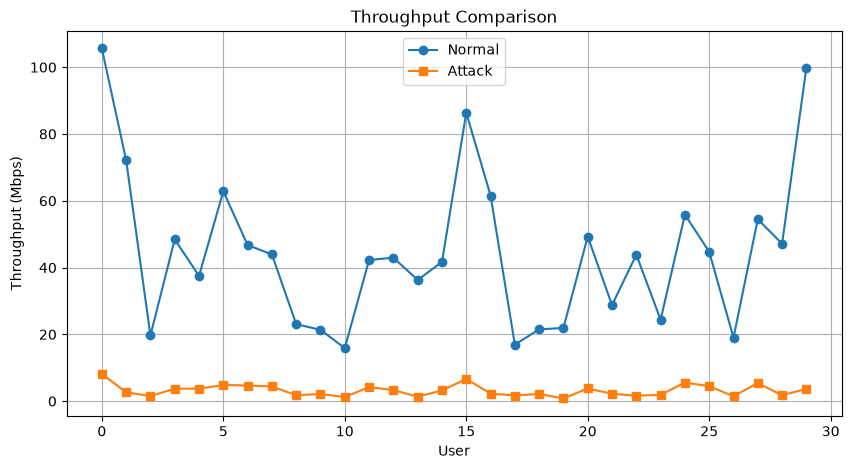

In [ ]:
# Plot Throughput Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_throughput,
         marker='o',
         label="Normal")

plt.plot(attack_throughput,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Throughput (Mbps)")

plt.title("Throughput Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_throughput_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# New Latency
attack_latency = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    load_factor = attack_cell_load[bs] / cell_load[bs]

    attack_latency[i] = latency[i] * load_factor

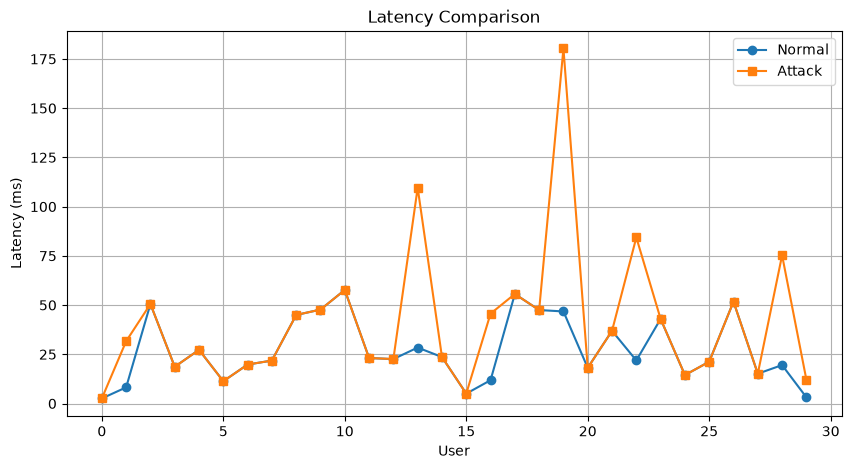

In [ ]:
# Plot Latency Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_latency,
         marker='o',
         label="Normal")

plt.plot(attack_latency,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Latency Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# QoS Comparison
print("========== NORMAL ==========")

print("Average Throughput:",
      np.mean(normal_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(normal_latency),
      "ms")

print("\n========== ATTACK ==========")

print("Average Throughput:",
      np.mean(attack_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(attack_latency),
      "ms")

========== NORMAL ==========
Average Throughput: 44.5359455635248 Mbps
Average Latency: 27.331081130877926 ms

========== ATTACK ==========
Average Throughput: 3.2132257521156187 Mbps
Average Latency: 40.63831775120253 ms


In [ ]:
# Save Results
attack_results = results.copy()

attack_results["Attack_Throughput_Mbps"] = attack_throughput
attack_results["Attack_Latency_ms"] = attack_latency

attack_results.to_csv(
    "results_step7_attack_results.csv",
    index=False
)

In [ ]:
# ====================================================
# STEP 7A - Legitimate Traffic Generation
# ====================================================

# Simulation Parameters
import numpy as np

simulation_time = 10          # seconds

packet_size = 1500            # Bytes

time_step = 1                 # second

# Legitimate Traffic
np.random.seed(42)

traffic_rate = np.random.randint(5,16,size=len(user_positions))

print(traffic_rate)

# Total Legitimate Packets
legitimate_packets = traffic_rate * simulation_time

print(legitimate_packets)

[11  8 15 12  9 11 14  7 11 15 15 12  9  8 12 12  7 10  9  6 12 10  6  9
  5 14 10 13  5 15]
[110  80 150 120  90 110 140  70 110 150 150 120  90  80 120 120  70 100
  90  60 120 100  60  90  50 140 100 130  50 150]


In [ ]:
# Spoofed Traffic
attack_levels = {
    "Normal":0,
    "Low":50,
    "Medium":200,
    "High":500
}

target_bs = 1 # Suppose the attacker targets BS2

spoofed_packets = attack_levels["Medium"] * simulation_time

print(spoofed_packets)

2000


In [ ]:
# Base Station Load
bs_packets = np.zeros(len(bs_positions))

for i,bs in enumerate(assignments_signal):

    bs_packets[bs] += legitimate_packets[i]

print(bs_packets)

# Inject Attack
attack_packets = bs_packets.copy()

attack_packets[target_bs] += spoofed_packets

print(attack_packets)

[1080.  550. 1490.]
[1080. 2550. 1490.]


In [ ]:
# Queue Model
bs_capacity = 2000      # packets

queue = np.maximum(
    attack_packets-bs_capacity,
    0
)

print(queue)

[  0. 550.   0.]


In [ ]:
# Queue Delay
queue_delay = queue / bs_capacity

print(queue_delay)

[0.    0.275 0.   ]


In [ ]:
# User Latency
attack_latency = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    attack_latency[i] = latency[i] + queue_delay[bs]*1000

In [ ]:
# Throughput Reduction
bs_capacity_Mbps = 1000

attack_throughput = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    load = attack_packets[bs]

    attack_throughput[i] = (
        throughput_Mbps[i]
        *
        bs_capacity
        /
        load
    )

In [ ]:
# Packet Loss
packet_loss = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):

    if attack_packets[i] > bs_capacity:

        packet_loss[i] = (
            attack_packets[i]-bs_capacity
        ) / attack_packets[i]
packet_loss1 = packet_loss*100
print(packet_loss1, "%")

[ 0.         21.56862745  0.        ] %


In [ ]:
# Visulaization --- do later Base Station Queue Length vs Attack Level
# Throughput vs Attack Level
# Latency vs Attack Level
# Packet Loss vs Attack Level
# Cell Load vs Attack Level
# User Assignment Map
# QoS Heat Map

In [ ]:
# ====================================================
# STEP 8 - Impact Assessment
# ====================================================

attack_levels = {
    "Normal": 0,
    "Low": 50,
    "Medium": 200,
    "High": 500
}

bs_capacity = 2000          # packets
simulation_time = 10        # seconds
target_bs = 1               # BS2

# Create Lists to Store Results
average_throughput = []
average_latency = []
average_packet_loss = []
average_queue = []

# Run All Attack Scenarios
for attack_name, attack_rate in attack_levels.items():

    spoofed_packets = attack_rate * simulation_time

    attack_packets = bs_packets.copy()

    attack_packets[target_bs] += spoofed_packets

    queue = np.maximum(attack_packets-bs_capacity,0)

    queue_delay = queue/bs_capacity

    attack_latency = np.zeros(len(user_positions))

    attack_throughput = np.zeros(len(user_positions))

    for i,bs in enumerate(assignments_signal):

        attack_latency[i] = latency[i] + queue_delay[bs]*1000

        attack_throughput[i] = (
            throughput_Mbps[i]
            *
            bs_capacity
            /
            attack_packets[bs]
        )

    packet_loss = np.zeros(len(bs_positions))

    for bs in range(len(bs_positions)):

        if attack_packets[bs] > bs_capacity:

            packet_loss[bs] = (
                attack_packets[bs]-bs_capacity
            )/attack_packets[bs]

    average_throughput.append(np.mean(attack_throughput))

    average_latency.append(np.mean(attack_latency))

    average_packet_loss.append(np.mean(packet_loss))

    average_queue.append(np.mean(queue))

# Display Results
import pandas as pd

impact_results = pd.DataFrame({

    "Attack_Level": attack_levels.keys(),

    "Avg_Throughput_Mbps": average_throughput,

    "Avg_Latency_ms": average_latency,

    "Avg_Queue_Packets": average_queue,

    "Avg_Packet_Loss": average_packet_loss

})

print(impact_results)


  Attack_Level  Avg_Throughput_Mbps  Avg_Latency_ms  Avg_Queue_Packets  \
0       Normal            95.599264       27.331081           0.000000   
1          Low            73.502049       27.331081           0.000000   
2       Medium            59.203851       91.497748         183.333333   
3         High            53.793722      441.497748        1183.333333   

   Avg_Packet_Loss  
0         0.000000  
1         0.000000  
2         0.071895  
3         0.213213  


In [ ]:
# Save Results
impact_results.to_csv(
    "results_step8_impact_assessment.csv",
    index=False
)

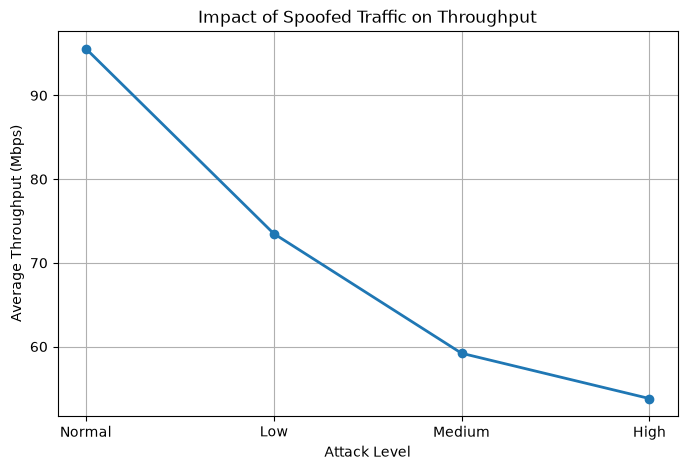

In [ ]:
# Throughput vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Throughput_Mbps"],
    marker='o',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Throughput (Mbps)")

plt.title("Impact of Spoofed Traffic on Throughput")

plt.grid(True)

plt.savefig(
    "figures_step8_throughput_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

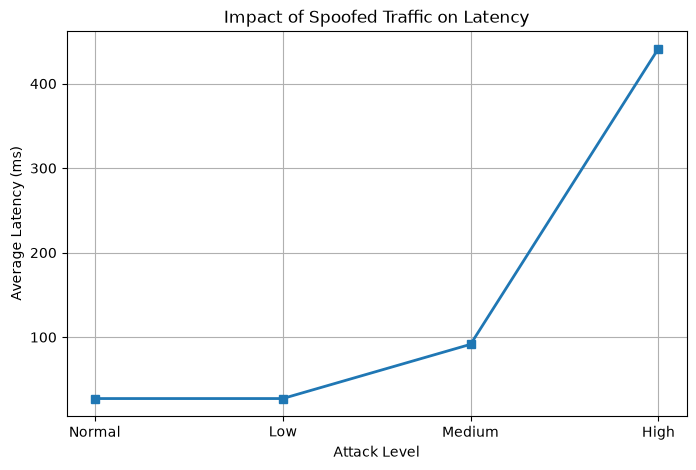

In [ ]:
#Latency vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Latency_ms"],
    marker='s',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Latency (ms)")

plt.title("Impact of Spoofed Traffic on Latency")

plt.grid(True)

plt.savefig(
    "figures_step8_latency_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

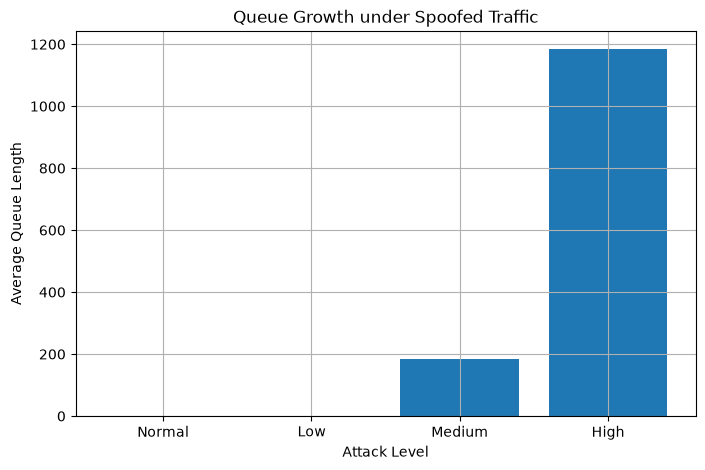

In [ ]:
# Queue Length
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Queue_Packets"]
)

plt.xlabel("Attack Level")

plt.ylabel("Average Queue Length")

plt.title("Queue Growth under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_queue_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

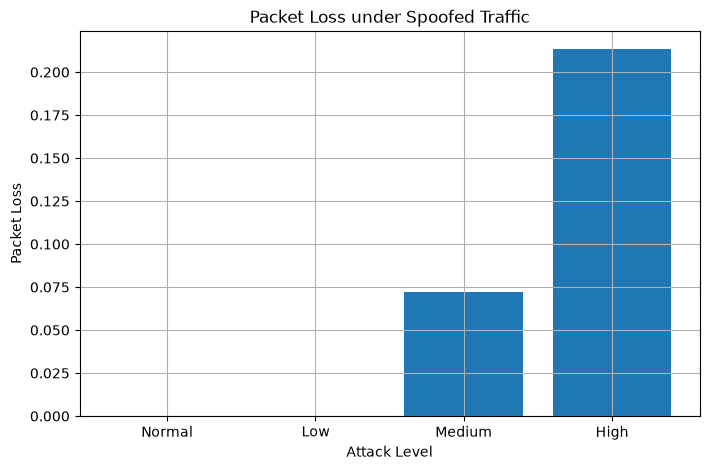

In [ ]:
# Packet Loss
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Packet_Loss"]
)

plt.xlabel("Attack Level")

plt.ylabel("Packet Loss")

plt.title("Packet Loss under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_packet_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

# Import Sionna Modules
from sionna.phy.channel import AWGN
from sionna.phy.mapping import Mapper
from sionna.phy.mapping import Demapper

print("Modules Imported Successfully")

TensorFlow: 2.20.0
Sionna: 2.0.1
Modules Imported Successfully


In [ ]:
# Simulation Parameters
NUM_BITS = 10000

SNR_dB = np.arange(0,21,2)

ber = []

# Generate Random Bits
bits = tf.random.uniform(
    [NUM_BITS],
    maxval=2,
    dtype=tf.int32
)

print(bits[:20])

tf.Tensor([0 0 1 0 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0], shape=(20,), dtype=int32)


In [ ]:
# BPSK Mapping
symbols = 2*tf.cast(bits,tf.float32)-1

print(symbols[:20])

tf.Tensor(
[-1. -1.  1. -1.  1.  1. -1.  1. -1.  1.  1. -1. -1. -1.  1.  1.  1.  1.
  1. -1.], shape=(20,), dtype=float32)


In [ ]:
print("SNR_dB:", SNR_dB)
print("Length of SNR_dB:", len(SNR_dB))

print("BER:", ber)
print("Length of BER:", len(ber))
print(ber)

SNR_dB: [ 0  2  4  6  8 10 12 14 16 18 20]
Length of SNR_dB: 11
BER: []
Length of BER: 0
[]


In [ ]:
# AWGN Channel
ber = []
for snr in SNR_dB:

    sigma = np.sqrt(1/(2*10**(snr/10)))

    noise = sigma*tf.random.normal(symbols.shape)

    rx = symbols+noise

    detected=tf.cast(rx>0,tf.int32)

    errors=tf.reduce_sum(
        tf.cast(
            detected!=bits,
            tf.int32
        )
    )

    ber.append(errors.numpy()/NUM_BITS)

In [ ]:
print(ber)
len(ber)

[np.float64(0.0748), np.float64(0.0379), np.float64(0.0101), np.float64(0.0018), np.float64(0.0002), np.float64(0.0001), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


11

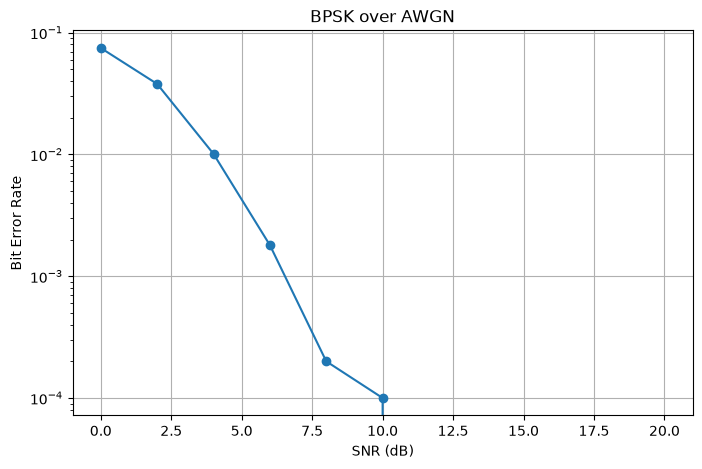

In [ ]:
SNR_dB = np.arange(0,21,2)
# BER Curve
plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    ber,
    marker='o'
)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Bit Error Rate")

plt.title("BPSK over AWGN")

plt.savefig(
    "figures_step9_ber_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import sionna

print(dir(sionna))
print("Sionna Version:", sionna.__version__)

['ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'importlib', 'phy', 'pkgutil']
Sionna Version: 2.0.1


In [ ]:
import pkgutil
import sionna

print("Available Sionna Modules\n")

for module in pkgutil.iter_modules(sionna.__path__):
    print(module.name)

Available Sionna Modules

phy
rt
sys


In [ ]:
import sionna.phy

print(dir(sionna.phy))

['ALPHA_MAX', 'BOLTZMANN_CONSTANT', 'Block', 'DIELECTRIC_PERMITTIVITY_VACUUM', 'H', 'Object', 'PI', 'Precision', 'SPEED_OF_LIGHT', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'block', 'channel', 'config', 'constants', 'dtypes', 'fec', 'mapping', 'mimo', 'nr', 'object', 'ofdm', 'scipy', 'signal', 'utils']


In [ ]:
import pkgutil
import sionna.phy

print("Available PHY Packages\n")

for module in pkgutil.iter_modules(sionna.phy.__path__):
    print(module.name)

Available PHY Packages

block
channel
config
constants
fec
mapping
mimo
nr
object
ofdm
signal
utils


In [ ]:
import sionna.phy.channel

print(dir(sionna.phy.channel))

import sionna.phy.ofdm

print(dir(sionna.phy.ofdm))

import sionna.phy.channel as ch

print(dir(ch))

import sionna.phy.ofdm as ofdm

print(dir(ofdm))


['AWGN', 'ApplyFlatFadingChannel', 'ApplyOFDMChannel', 'ApplyTimeChannel', 'BinaryErasureChannel', 'BinaryMemorylessChannel', 'BinarySymmetricChannel', 'BinaryZChannel', 'CIRDataset', 'ChannelModel', 'DEFAULT_L_MIN', 'EDFA', 'FlatFadingChannel', 'GenerateFlatFadingChannel', 'GenerateOFDMChannel', 'GenerateTimeChannel', 'KroneckerModel', 'OFDMChannel', 'PerColumnModel', 'RayleighBlockFading', 'SSFM', 'SpatialCorrelation', 'TimeChannel', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_ofdm_channel', 'apply_time_channel', 'awgn', 'channel_model', 'cir_dataset', 'cir_to_ofdm_channel', 'cir_to_time_channel', 'constants', 'deg_2_rad', 'discrete_channel', 'drop_uts_in_sector', 'exp_corr_mat', 'flat_fading_channel', 'gen_single_sector_topology', 'gen_single_sector_topology_interferers', 'generate_ofdm_channel', 'generate_time_channel', 'generate_uts_topology', 'ofdm_channel', 'one_ring_corr_mat', 'optical', 'rad_2_deg

In [ ]:
# ======================================================
# STEP 10 - Sionna PHY Integration
# Small-Scale Fading
# ======================================================

import tensorflow as tf
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

num_users = len(user_positions)

In [ ]:
# Rayleigh fading coefficient

# Real part
real = tf.random.normal([num_users], dtype=tf.float32)

# Imaginary part
imag = tf.random.normal([num_users], dtype=tf.float32)

# Create complex channel coefficients
h = tf.complex(real, imag) / tf.cast(tf.sqrt(2.0), tf.complex64)

print(h[:10])

tf.Tensor(
[ 0.23155521+5.9555773e-02j -0.59582645-6.0875088e-01j
  0.22587374+2.6737338e-01j -0.9952895 -3.6743204e-03j
 -1.6886133 -3.4968692e-01j -0.7348592 +4.3686414e-01j
 -0.39408705-2.3392540e-01j  0.38163048-9.7869278e-04j
  1.2016801 -2.9962525e-01j  0.204309  -9.8090470e-01j], shape=(10,), dtype=complex64)


In [ ]:
# Channel Power Gain
channel_gain = tf.abs(h)**2

channel_gain = channel_gain.numpy()

print(channel_gain[:10])

[0.0571647  0.7255867  0.12250746 0.9906148  2.9736955  0.7308684
 0.2100257  0.14564277 1.5338103  1.0039163 ]


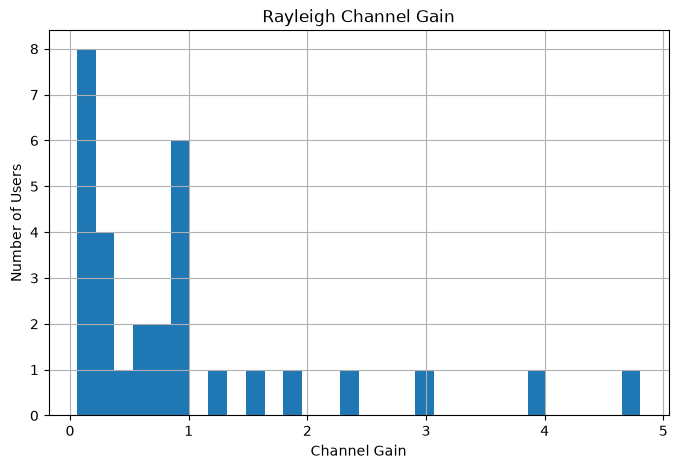

In [ ]:
# Plot the Fading Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(channel_gain,
         bins=30)

plt.xlabel("Channel Gain")

plt.ylabel("Number of Users")

plt.title("Rayleigh Channel Gain")

plt.grid(True)

plt.savefig(
    "figures_step10_channel_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
received_power
channel_gain = channel_gain.reshape(-1, 1)

received_power_fading = received_power + 10*np.log10(channel_gain)

print(received_power_fading[:10])

[[-80.59857215 -79.8351827  -61.40467891]
 [-66.99739134 -54.23781418 -68.63484481]
 [-81.10189092 -76.91152052 -75.60046516]
 [-66.85456907 -65.64424295 -56.80142134]
 [-53.17769331 -58.96939984 -62.71700325]
 [-68.98271743 -70.84420652 -57.86473627]
 [-68.75837552 -77.57317046 -78.14464841]
 [-71.00352562 -79.00763462 -80.19603123]
 [-69.04054944 -64.82678832 -62.55266967]
 [-61.96184051 -63.27101369 -69.59835223]]


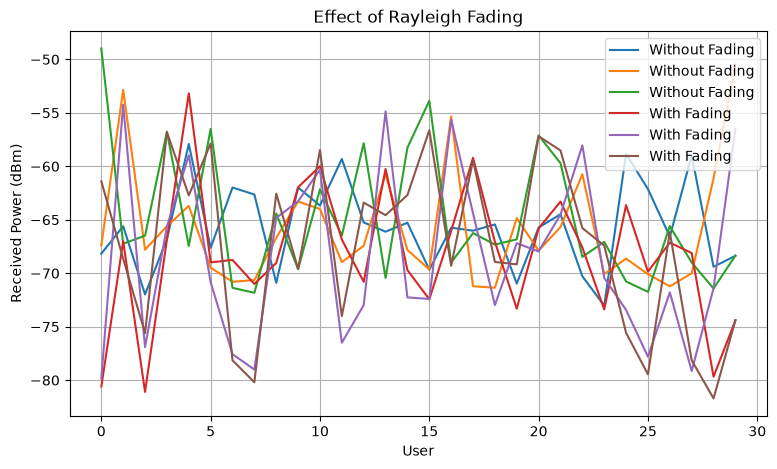

In [ ]:
# Plot the Difference
plt.figure(figsize=(9,5))

plt.plot(received_power,
         label="Without Fading")

plt.plot(received_power_fading,
         label="With Fading")

plt.xlabel("User")

plt.ylabel("Received Power (dBm)")

plt.title("Effect of Rayleigh Fading")

plt.legend()

plt.grid(True)

plt.savefig(
    "figures_step10_received_power_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Recalculate SINR
received_power_mW = 10**(received_power_fading/10)

noise_power = 1e-10

sinr = received_power_mW / noise_power

sinr_dB = 10*np.log10(sinr)

print(sinr_dB[:10])

[[19.40142785 20.1648173  38.59532109]
 [33.00260866 45.76218582 31.36515519]
 [18.89810908 23.08847948 24.39953484]
 [33.14543093 34.35575705 43.19857866]
 [46.82230669 41.03060016 37.28299675]
 [31.01728257 29.15579348 42.13526373]
 [31.24162448 22.42682954 21.85535159]
 [28.99647438 20.99236538 19.80396877]
 [30.95945056 35.17321168 37.44733033]
 [38.03815949 36.72898631 30.40164777]]


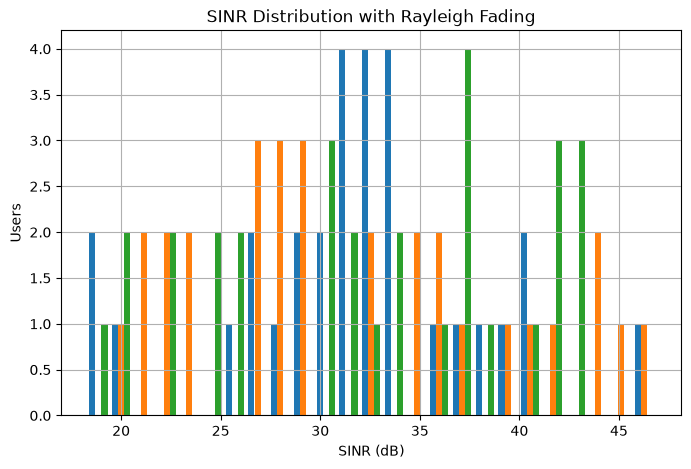

In [ ]:
# Compare SINR
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=25)

plt.xlabel("SINR (dB)")

plt.ylabel("Users")

plt.title("SINR Distribution with Rayleigh Fading")

plt.grid(True)

plt.savefig(
    "figures_step10_sinr_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# =====================================================
# STEP 11 - Beamforming
# =====================================================

beamforming_gain_dB = 6

print("Beamforming Gain:", beamforming_gain_dB, "dB")

received_power_beamforming = received_power_fading + beamforming_gain_dB

print(received_power_beamforming[:5])
print(received_power_fading.shape)

Beamforming Gain: 6 dB
[[-74.59857215 -73.8351827  -55.40467891]
 [-60.99739134 -48.23781418 -62.63484481]
 [-75.10189092 -70.91152052 -69.60046516]
 [-60.85456907 -59.64424295 -50.80142134]
 [-47.17769331 -52.96939984 -56.71700325]]
(30, 3)


In [ ]:
# Calculate New SINR
received_power_mW = 10 ** (received_power_beamforming / 10)
# Assume:
noise_power_mW = 1e-10

sinr_beam = received_power_mW / noise_power_mW

sinr_beam_dB = 10 * np.log10(sinr_beam)

In [ ]:
# Compare Average SINR
print("Average SINR without Beamforming:")

print(np.mean(sinr_dB))

print()

print("Average SINR with Beamforming:")

print(np.mean(sinr_beam_dB))

Average SINR without Beamforming:
31.96509381506488

Average SINR with Beamforming:
37.965093815064876


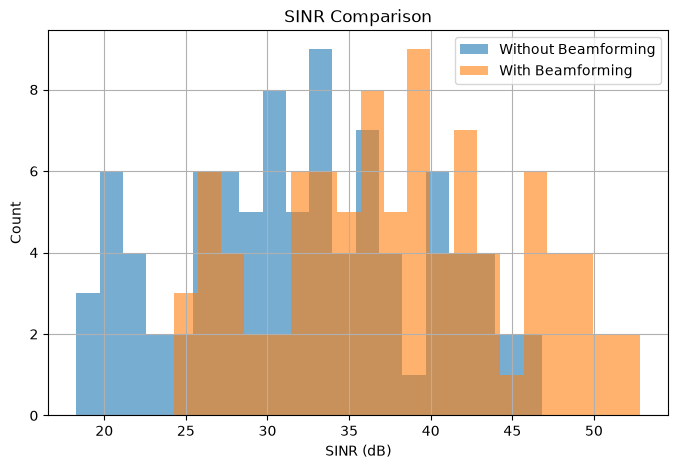

In [ ]:
# Plot the Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    sinr_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="Without Beamforming"
)

plt.hist(
    sinr_beam_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="With Beamforming"
)

plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.title("SINR Comparison")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_sinr_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Count Users Per Base Station
num_bs = received_power_beamforming.shape[1]

users_per_bs = np.bincount(
    assignments_beamforming,
    minlength=num_bs
)

for bs in range(num_bs):
    print(f"BS {bs+1}: {users_per_bs[bs]} users")

BS 1: 10 users
BS 2: 7 users
BS 3: 13 users


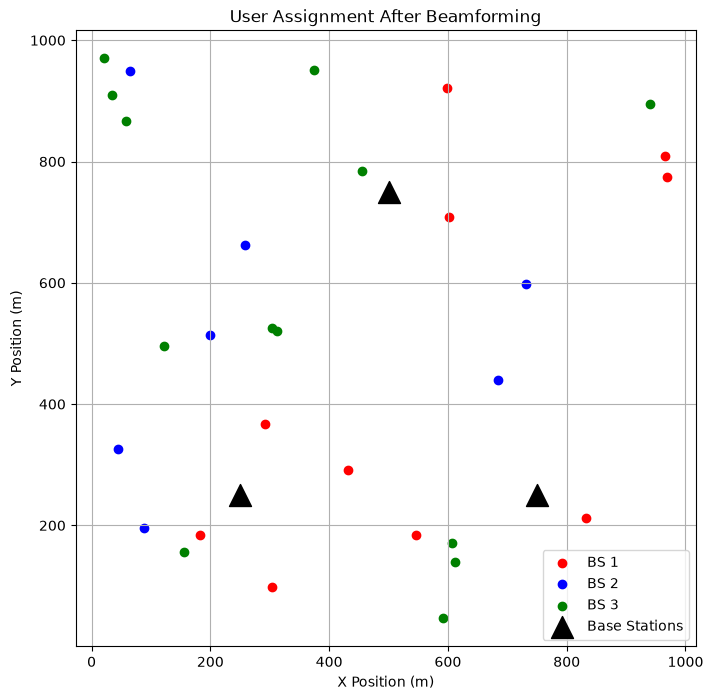

In [ ]:
# Visualize User Assignment
colors = ["red", "blue", "green"]

plt.figure(figsize=(8,8))

for bs in range(num_bs):

    users = user_positions[
        assignments_beamforming == bs
    ]

    plt.scatter(
        users[:,0],
        users[:,1],
        color=colors[bs],
        label=f"BS {bs+1}"
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker="^",
    s=250,
    color="black",
    label="Base Stations"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("User Assignment After Beamforming")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_user_assignment_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()